In [119]:
import pandas as pd

df = pd.read_csv("mall_customers.csv")

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [120]:
print(df.info())

print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000      

In [121]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


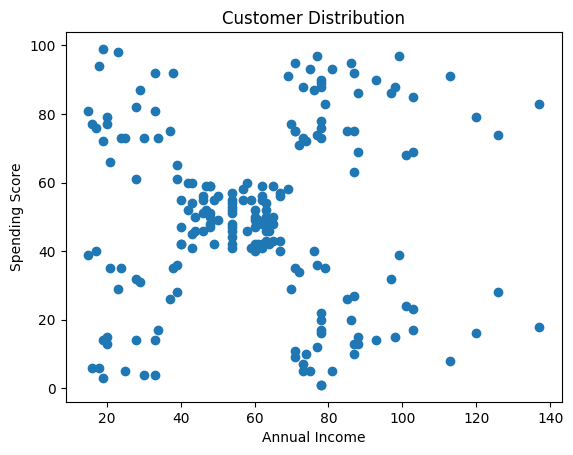

In [122]:
import matplotlib.pyplot as plt

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")

plt.show()

In [123]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

kmeans.fit(X)

print("K-Means trained!")

K-Means trained!


In [124]:
clusters = kmeans.labels_

print(clusters[:20])

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2]


In [125]:
df["Cluster"] = clusters

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


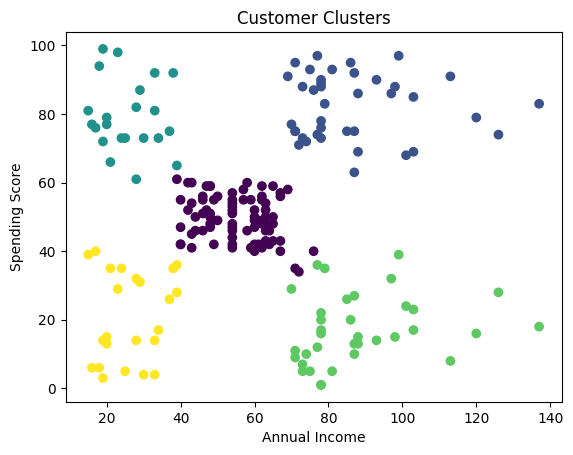

In [126]:
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=clusters
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Clusters")

plt.show()

In [127]:
inertia_values = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X)

    inertia_values.append(kmeans.inertia_)

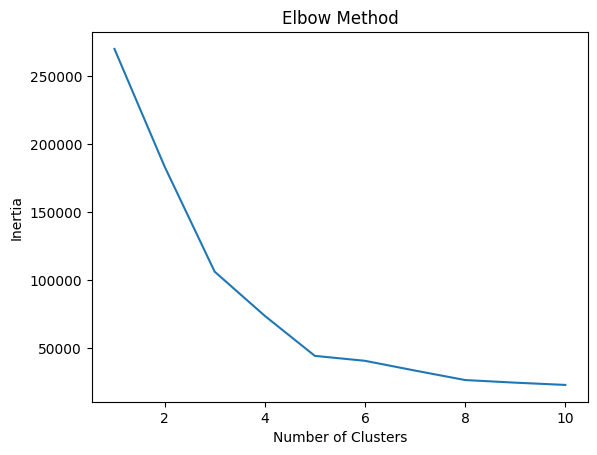

In [128]:
plt.plot(range(1, 11), inertia_values)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [129]:
centroids = kmeans.cluster_centers_

print(centroids)

[[ 56.46478873  49.77464789]
 [ 97.09090909  86.09090909]
 [ 79.          16.59259259]
 [ 23.42857143  84.78571429]
 [ 24.58333333   9.58333333]
 [ 76.96        80.8       ]
 [ 31.53333333  35.86666667]
 [109.7         22.        ]
 [ 33.5         66.25      ]
 [127.66666667  78.66666667]]


In [130]:
from sklearn.decomposition import PCA

In [131]:
features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features]

In [132]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [133]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca[:5])

[[-0.61572002 -1.76348088]
 [-1.66579271 -1.82074695]
 [ 0.33786191 -1.67479894]
 [-1.45657325 -1.77242992]
 [-0.03846521 -1.66274012]]


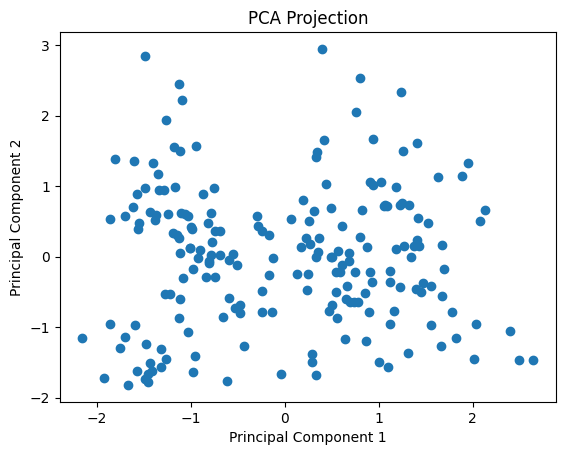

In [134]:
import matplotlib.pyplot as plt

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")

plt.show()

In [135]:
print(pca.explained_variance_ratio_)

[0.44266167 0.33308378]


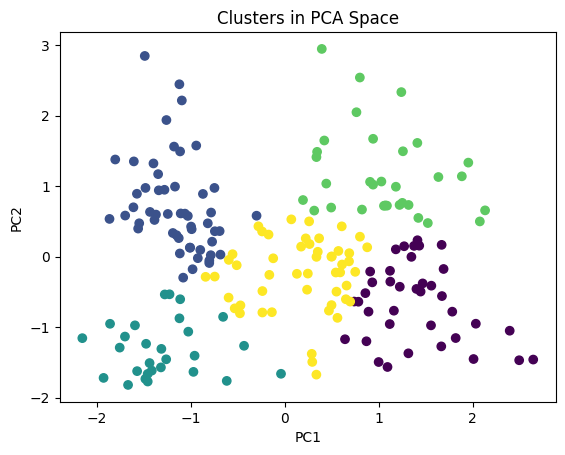

In [136]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_pca)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters in PCA Space")

plt.show()